# Importacion de funciones  

In [47]:
import dolfinx
import gmsh
import numpy as np
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx.fem import (Constant, Function, dirichletbc,assemble_vector)
from dolfinx.fem.petsc import  (NonlinearProblem,apply_lifting, set_bc)
from dolfinx.io import gmshio
from ufl import (TestFunctions, div,dx, dot, inner, grad, split)
from dolfinx.nls.petsc import NewtonSolver
import basix.ufl
from dolfinx.io import XDMFFile
from pydmd import DMD
from dolfinx.io import VTKFile
from dolfinx.fem.petsc import create_vector
from petsc4py import PETSc
from dolfinx.fem.petsc import assemble_vector, apply_lifting, set_bc
from dolfinx import fem
from ufl import TestFunction, TrialFunction, TestFunctions, derivative
from petsc4py import PETSc
import ufl
from dolfinx.fem.petsc import create_vector
from petsc4py import PETSc
from dolfinx.fem.petsc import assemble_vector, apply_lifting, set_bc
from dolfinx import fem
from ufl import TestFunction, TrialFunction, TestFunctions, derivative
from petsc4py import PETSc
import ufl
from dolfinx.fem import form, assemble_vector
import dolfinx
from dolfinx import log
import os
import numpy as np
from dolfinx import fem, io
from mpi4py import MPI

print(dolfinx.__version__)

0.8.0


## Computational Domain Discretization

The numerical simulation begins with the construction of the computational domain and its discretization into finite elements. The domain considered is a two-dimensional unit square cavity, a classical benchmark problem in computational fluid dynamics (CFD) widely used to assess numerical methods for incompressible flows.

To accurately represent the physical problem, the fluid region and its boundaries are identified through physical markers. These markers allow the imposition of different boundary conditions on the moving lid and the stationary walls, which are essential for reproducing the lid-driven cavity configuration.

Once the geometry is defined, a structured finite element mesh is generated over the domain. The mesh subdivides the continuous fluid region into a finite number of elements, creating the approximation space in which the velocity and pressure fields are represented. In this study, second-order elements are employed to improve the accuracy of the spatial discretization and provide a more faithful representation of the flow field.

The resulting discretized domain constitutes the foundation of the finite element formulation of the Navier–Stokes equations, transforming the continuous governing equations into a finite-dimensional system that can be solved numerically.

In [48]:
# Comunicador MPI y proceso que construirá la geometría
mesh_comm = MPI.COMM_WORLD
model_rank = 0

# Inicializar Gmsh
gmsh.initialize()

# Crear nuevo modelo llamado "cavity"
gmsh.model.add("cavity")

# =========================
# Geometría de la cavidad
# =========================

L = 1.0  # Largo en x
H = 1.0  # Altura en y
gdim = 2  # Dimensión geométrica (2D)

# Solo el proceso principal crea la geometría
if mesh_comm.rank == model_rank:
    # Crear rectángulo desde (0,0) con dimensiones L x H
    rectangle = gmsh.model.occ.addRectangle(0, 0, 0, L, H)

    # Sincronizar modelo CAD con el modelo Gmsh
    gmsh.model.occ.synchronize()


# =========================
# Dominio fluido (marcador de celdas)
# =========================

fluid_marker = 1  # Identificador físico del dominio

if mesh_comm.rank == model_rank:
    # Obtener entidades 2D (superficie del rectángulo)
    volumes = gmsh.model.getEntities(dim=gdim)

    # Asociar superficie al grupo físico "Fluid"
    gmsh.model.addPhysicalGroup(gdim, [volumes[0][1]], fluid_marker)
    gmsh.model.setPhysicalName(gdim, fluid_marker, "Fluid")


# =========================
# Marcadores de frontera
# =========================

lid_marker = 2   # Tapa superior
wall_marker = 3  # Otras paredes

lid = []    # Lista para almacenar la frontera superior
walls = []  # Lista para almacenar las otras tres paredes

if mesh_comm.rank == model_rank:
    # Obtener las fronteras del dominio 2D (dim=1)
    boundaries = gmsh.model.getBoundary(volumes, oriented=False)

    for boundary in boundaries:
        # Calcular centro de masa de cada borde
        com = gmsh.model.occ.getCenterOfMass(boundary[0], boundary[1])

        # Si el centro de masa tiene y = H → es la tapa superior
        if np.isclose(com[1], H):
            lid.append(boundary[1])
        else:
            walls.append(boundary[1])

    # Crear grupo físico para la tapa
    gmsh.model.addPhysicalGroup(1, lid, lid_marker)
    gmsh.model.setPhysicalName(1, lid_marker, "Lid")

    # Crear grupo físico para las paredes restantes
    gmsh.model.addPhysicalGroup(1, walls, wall_marker)
    gmsh.model.setPhysicalName(1, wall_marker, "Walls")


# =========================
# Generación de malla
# =========================

if mesh_comm.rank == model_rank:
    # Tamaño uniforme de elemento
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 0.02)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 0.02)

    # Generar malla 2D
    gmsh.model.mesh.generate(gdim)

    # Elevar orden de elementos a cuadráticos (P2)
    gmsh.model.mesh.setOrder(2)

    # ==================================
    # RESUMEN AUTOMÁTICO DE LA MALLA
    # ==================================

    print("\n========== RESUMO DA MALHA ==========")

    # --- Entidades geométricas ---
    puntos_geom = len(gmsh.model.getEntities(0))
    lineas_geom = len(gmsh.model.getEntities(1))
    superficies_geom = len(gmsh.model.getEntities(2))

    print("Pontos geométricos:", puntos_geom)
    print("Linhas geométricas:", lineas_geom)
    print("Superfícies (2D):", superficies_geom)

    # --- Nodos totales ---
    nodeTags, nodeCoords, _ = gmsh.model.mesh.getNodes()
    total_nodos = len(nodeTags)
    print("Nós totais:", total_nodos)

    # --- Elementos por tipo ---
    elemTypes, elemTags, elemNodeTags = gmsh.model.mesh.getElements()

    total_elementos = 0

    for i, elemType in enumerate(elemTypes):
        nome, dim, ordem, numNodes, localNodes, _ = \
            gmsh.model.mesh.getElementProperties(elemType)

        cantidad = len(elemTags[i])
        total_elementos += cantidad

        print(f"{nome} (dim={dim}) :", cantidad)

    print("Elementos totais:", total_elementos)
    print("=====================================\n")


# =========================
# Conversión a DOLFINx
# =========================

# Convertir modelo Gmsh a objeto mesh de DOLFINx
mesh, c, ft = gmshio.model_to_mesh(
    gmsh.model, mesh_comm, model_rank, gdim=gdim
)

# Asignar nombres internos
mesh.name = "Cavity"
c.name = "Cell markers"
ft.name = "Facet markers"

# Mostrar interfaz gráfica de Gmsh (opcional)
gmsh.fltk.run()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.000443776s, CPU 0.000865s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.12503s, CPU 0.125252s)
Info    : 3016 nodes 6034 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 30%] Meshing curve 2 order 2
Info    : [ 50%] Meshing curve 3 order 2
Info    : [ 70%] Meshing curve 4 order 2
Info    : [ 90%] Meshing surface 1 order 2
Info    : Surface mesh: worst distortion = 1 (0 elements in ]0, 0.2]); worst gamma = 0.882045
Info    : Done meshing order 2 (Wall 0.0202682s, CPU 0.020366s)

========== RESUMO DA MALHA ==========
Pontos geométricos: 4
Linhas geométricas: 4
Superfícies (2D): 1
Nós totais: 11861
Line 3 (dim=1) : 200
Triangle 6 (dim=2) : 5830
Point 

-------------------------------------------------------
Version       : 4.15.1
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260216
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


## Finite Element Formulation and Numerical Solution Strategy

After constructing the computational mesh, the incompressible Navier–Stokes equations are discretized using the finite element method. The velocity field is approximated using quadratic Lagrange elements, while the pressure field is represented using linear Lagrange elements, resulting in the classical Taylor–Hood mixed formulation. This element pair satisfies the inf-sup stability condition and is widely employed for incompressible flow simulations.

Time integration is performed through the generalized θ-method. By selecting θ = 1, the formulation reduces to the fully implicit backward Euler scheme, providing unconditional stability for the diffusive terms and improved robustness for nonlinear flow problems.

The variational formulation includes the transient term, viscous diffusion, nonlinear convective transport, and the incompressibility constraint. The resulting system constitutes a coupled nonlinear problem for the velocity and pressure fields, which must be solved at each time step.

Boundary conditions are imposed through Dirichlet constraints. A constant horizontal velocity is prescribed on the upper boundary to generate the cavity circulation, while no-slip conditions are enforced on the remaining walls. Since pressure is defined only up to an arbitrary constant in incompressible flows, a reference pressure value is prescribed at a single point of the domain to ensure uniqueness of the solution.

The nonlinear algebraic system arising from the finite element discretization is solved using Newton's method. At each Newton iteration, a linearized system is assembled and solved through a Krylov subspace method (GMRES) combined with a direct LU factorization using the MUMPS parallel sparse solver. This approach provides a robust and efficient solution strategy for the coupled velocity–pressure problem.


In [49]:
# =========================
# Parámetros
# =========================

dt = Constant(mesh, PETSc.ScalarType(0.1))
nu = Constant(mesh, PETSc.ScalarType(0.001/1))

T = 30
theta = 1
U_0 = 1.5

fdim = mesh.topology.dim - 1

# =========================
# Espacios funcionales
# =========================

V_element = basix.ufl.element(
    "Lagrange",
    mesh.basix_cell(),
    2,
    shape=(mesh.geometry.dim,)
)

Q_element = basix.ufl.element(
    "Lagrange",
    mesh.basix_cell(),
    1
)

W_element = basix.ufl.mixed_element([V_element, Q_element])
W = dolfinx.fem.functionspace(mesh, W_element)

V, _ = W.sub(0).collapse()
Q, _ = W.sub(1).collapse()

# =========================
# Funciones
# =========================

up = Function(W)
u, p = split(up)

up_old = Function(W)
u_old, p_old = split(up_old)

(v, q) = TestFunctions(W)

# =========================
# Formulación variacional
# =========================

F = (
    (1/dt)*dot(u - u_old, v)
    + theta*nu*inner(grad(u), grad(v))
    + theta*dot(dot(grad(u), u), v)
    + (1-theta)*nu*inner(grad(u_old), grad(v))
    + (1-theta)*dot(dot(grad(u_old), u_old), v)
    - p*div(v)
    - q*div(u)
) * dx


############################################
# Condiciones de contorno - Cavidad
############################################

# ----- Tapa móvil (marker = 2)

def u_lid_eval(x):
    values = np.zeros((2, x.shape[1]))
    values[0, :] = U_0
    return values

u_lid = Function(V)
u_lid.interpolate(u_lid_eval)

lid_dofs = dolfinx.fem.locate_dofs_topological(
    (W.sub(0), V),
    fdim,
    ft.indices[ft.values == 2]
)

bcu_lid = dolfinx.fem.dirichletbc(u_lid, lid_dofs, W.sub(0))


# ----- Paredes (marker = 3)

def u_wall_eval(x):
    return np.zeros((2, x.shape[1]))

u_nonslip = Function(V)
u_nonslip.interpolate(u_wall_eval)

wall_dofs = dolfinx.fem.locate_dofs_topological(
    (W.sub(0), V),
    fdim,
    ft.indices[ft.values == 3]
)

bcu_walls = dolfinx.fem.dirichletbc(u_nonslip, wall_dofs, W.sub(0))


# ----- Fijar presión en un punto (correcto en 0.8)

p_zero = Function(Q)
p_zero.x.array[:] = 0.0

p_dofs = dolfinx.fem.locate_dofs_geometrical(
    (W.sub(1), Q),
    lambda x: np.logical_and(
        np.isclose(x[0], 0.0),
        np.isclose(x[1], 0.0)
    )
)

bcp_point = dolfinx.fem.dirichletbc(
    p_zero,
    p_dofs,
    W.sub(1)
)

bcu = [bcu_lid, bcu_walls]
bcp = [bcp_point]
bcs = bcu + bcp


# =========================
# Solver
# =========================

problem = NonlinearProblem(F, up, bcs)
solver = NewtonSolver(MPI.COMM_WORLD, problem)

solver.rtol = 1e-8
solver.atol = 1e-8
solver.max_it = 50
solver.convergence_criterion = "residual"
solver.report = True
solver.error_on_nonconvergence = False

ksp = solver.krylov_solver
ksp.setTolerances(rtol=1e-8)

opts = PETSc.Options()
option_prefix = ksp.getOptionsPrefix()

opts[f"{option_prefix}ksp_type"] = "gmres"
opts[f"{option_prefix}pc_type"] = "lu"
opts[f"{option_prefix}pc_factor_mat_solver_type"] = "mumps"

ksp.setFromOptions()

## Discrete Function Spaces and Degrees of Freedom

Before solving the nonlinear system, it is useful to examine the dimensions of the finite element spaces used in the discretization. The velocity and pressure approximation spaces contain the degrees of freedom (DOFs) that define the numerical solution.

For the Taylor–Hood formulation employed in this study, the velocity field is approximated using higher-order polynomial basis functions than the pressure field. Consequently, the velocity space typically contains a significantly larger number of degrees of freedom.

The mixed finite element space combines both velocity and pressure unknowns into a single coupled formulation. Inspecting the dimensions of the individual spaces and the mixed space provides valuable information about the size of the algebraic system to be solved and the computational resources required for the simulation.

The reported dimensions correspond to the total number of unknowns associated with each field after spatial discretization. These values serve as an indicator of the resolution of the numerical model and directly influence the memory consumption and computational cost of the simulation.


In [50]:
# Imprimimos el tamaño de los subespacios V y Q
print("Tamaño de V:", V.dofmap.index_map.size_local)
print("Tamaño de Q:", Q.dofmap.index_map.size_local)

# Espacio donde vou alamacenar velocidad 
V0, dofs = W.sub(0).collapse()

# Espacio donde vou alamacenar presion 
Q0, dofs_p = W.sub(1).collapse()

# Obtener los tamaños de V0 y Q0
print("Tamaño de V0:", V0.dofmap.index_map.size_local)
print("Tamaño de Q0:", Q0.dofmap.index_map.size_local)

print(type(bcp))  # ¿Es una lista?

print(f"Dimension V: {V.dofmap.index_map.size_global * V.dofmap.index_map_bs}")
print(f"Dimension Q: {Q.dofmap.index_map.size_global * Q.dofmap.index_map_bs}")
print(f"Dimension W: {W.dofmap.index_map.size_global * W.dofmap.index_map_bs}")

Tamaño de V: 11861
Tamaño de Q: 3016
Tamaño de V0: 11861
Tamaño de Q0: 3016
<class 'list'>
Dimension V: 23722
Dimension Q: 3016
Dimension W: 26738


## Projection of Solution Fields into the Mixed Space

In finite element computations, solution variables are often stored, manipulated, or post-processed in separate approximation spaces. However, the numerical formulation may require these variables to be represented within a unified mixed function space that simultaneously contains all unknown fields.

The following procedure reconstructs a mixed solution by combining previously computed velocity and pressure fields. First, the individual fields are represented in their corresponding finite element spaces. These fields are then transferred to the velocity and pressure components of the mixed space, producing a consistent representation of the complete solution state.

This operation preserves the finite element approximation while enabling subsequent computations to be performed using a single mixed variable. Such an approach is particularly useful for nonlinear solvers, time-dependent simulations, and reduced-order modeling frameworks, where the complete state vector must be manipulated as a unified object.


In [51]:
def transformar_Datos(u_array, p_array):
    
    # En el caso de la velocidad 
    u_proj = Function(V0)
    u_proj.x.array[:] = u_array
    u_proj.x.scatter_forward()

    # En el caso de la presion 
    p_proj = Function(Q0)
    p_proj.x.array[:] = p_array
    p_proj.x.scatter_forward()
    
    # Crear función en espacio mixto
    up = Function(W)
    u_sub, p_sub = up.split()

    # Interpolar los datos a los subespacios del espacio mixto
    u_sub.interpolate(u_proj)
    p_sub.interpolate(p_proj)
    up.x.scatter_forward()
    return up

# Calcular el residuo a partir de dos vectores 

## Nonlinear Residual Norm

Let

$
\mathbf{w}_h=(u_h,p_h)\in W_h
$

denote the discrete velocity–pressure solution and let

$
\mathcal{F}(\mathbf{w}_h)
$

represent the nonlinear finite element operator arising from the discretized Navier–Stokes equations. The solution of the nonlinear problem is obtained by seeking a state such that

$
\mathcal{F}(\mathbf{w}_h)=0.
$

For an arbitrary approximation (\mathbf{w}_h), the residual vector measures the departure from this equilibrium condition. After assembly and application of the boundary constraints, the residual norm is computed as

$
|\mathbf{R}|*2 =
\left(
\sum*{i=1}^{N} R_i^2
\right)^{1/2},
$

where $R_i$ are the components of the assembled residual vector.

The residual norm provides a quantitative measure of the satisfaction of the discrete governing equations and is commonly employed as a convergence criterion in Newton-type nonlinear solvers and reduced-order modeling methodologies.


In [52]:
def residual(vector1, vector2):
    up_old = vector1
    up = vector2
    bcs = bcu + bcp  
    u, p = split(up)
    u_old, p_old = split(up_old)

    F = (
        (1/dt)*dot(u - u_old, v)
        + (theta)*nu * inner(grad(u), grad(v))
        + (theta)*dot(dot(grad(u), u), v)
        + (1-theta)*nu * inner(grad(u_old), grad(v))
        + (1-theta)*dot(dot(grad(u_old), u_old), v)
        - p * div(v)
        - q * div(u)
    ) * dx

    # Parametros de la simulacion
    jacobian = ufl.derivative(F, up)
    J_compiled = dolfinx.fem.form(jacobian)
    F_compiled = dolfinx.fem.form(F)
    b = dolfinx.fem.Function(up.function_space)
    dolfinx.fem.assemble_vector(b.x.array, F_compiled)
    dolfinx.fem.apply_lifting(b.x.array, [J_compiled], [bcs], x0=[up.x.array], scale=-1.0)
    b.x.scatter_reverse(dolfinx.la.InsertMode.add)
    set_bc(b=b.vector, bcs=bcs, x0=up.vector)
    norma = np.linalg.norm(b.x.array)
    return norma

## Adaptive FOM–DMD Time Integration Strategy

The numerical simulation is performed using an adaptive hybrid framework that combines a full-order model (FOM) based on the finite element discretization of the Navier–Stokes equations with a reduced-order model (ROM) constructed through Dynamic Mode Decomposition (DMD).

During the initial stage of the simulation, a prescribed number of high-fidelity snapshots is generated using the full-order solver. These snapshots contain the temporal evolution of both velocity and pressure fields and are assembled into snapshot matrices that constitute the training data for the reduced-order model.

Let

$$
\mathbf{w}_n=(u_n,p_n)
$$

denote the discrete finite element solution at time level (t_n). During the training stage, a sequence of full-order solutions is computed and stored in the snapshot matrices

$$
\mathbf{X}_u =
\begin{bmatrix}
u_1 & u_2 & \cdots & u_m
\end{bmatrix},
$$

and

$$
\mathbf{X}_p =
\begin{bmatrix}
p_1 & p_2 & \cdots & p_m
\end{bmatrix}.
$$

These matrices contain the temporal evolution of the velocity and pressure fields and provide the information required to construct reduced-order representations of the flow dynamics.

Once a sufficient amount of information has been collected, Dynamic Mode Decomposition is applied independently to the velocity and pressure datasets. The resulting DMD operators approximate the temporal evolution of each field and are subsequently employed to predict future solution states without requiring the solution of the complete nonlinear finite element system.

The reduced-order model is then used to estimate the future state

$$
\mathbf{w}_{n+1}^{\mathrm{DMD}}.
$$

To ensure the reliability of the reduced-order approximation, a residual-based error indicator is evaluated. The nonlinear residual associated with the discretized Navier–Stokes equations is computed using the predicted velocity and pressure fields. This residual quantifies the extent to which the governing equations are satisfied by the DMD approximation.

Specifically, the predicted solution is accepted only if

$$
|\mathbf{R}(\mathbf{w}_{n+1}^{\mathrm{DMD}})|
<
\varepsilon,
$$

where (\varepsilon) denotes a prescribed tolerance.

If the residual norm remains below the tolerance, the reduced-order prediction is considered sufficiently accurate and replaces the full-order solve. In this situation, the DMD solution is incorporated into the snapshot database and becomes part of the evolving reduced-order representation.

Conversely, if the residual exceeds the prescribed tolerance, the reduced-order prediction is rejected and a new high-fidelity solution is computed through the finite element solver. The resulting full-order state is then obtained as

$$
\mathbf{w}_{n+1}^{\mathrm{FOM}}.
$$

This newly computed solution is subsequently added to the snapshot matrices, enriching the information available to the reduced-order model and improving future predictions.

The accepted solution, whether obtained from the reduced-order model or the full-order solver, is incorporated into the evolving database of snapshots. Consequently, the reduced-order model continuously adapts throughout the simulation and remains consistent with the most recent flow dynamics.

This adaptive procedure dynamically alternates between full-order and reduced-order evaluations, allowing significant computational savings while preserving consistency with the governing equations. The strategy can therefore be interpreted as an online model reduction framework in which the reduced model evolves continuously as new snapshots become available during the simulation.

The overall methodology creates an adaptive hybrid framework capable of balancing computational efficiency and physical accuracy. By combining residual-based validation with online enrichment of the snapshot database, the algorithm automatically determines when reduced-order predictions are sufficiently accurate and when additional high-fidelity simulations are required, thereby maintaining robustness while reducing the overall computational cost of the transient CFD simulation.


In [53]:
import warnings
warnings.filterwarnings("ignore")

# Crear archivo VTK para la presión (una vez, fuera del bucle de tiempo si usas uno)
vtkfile_p1 = VTKFile(mesh.comm, "resultados_mix/presion1.vtu", "w")

# Abrir archivo una sola vez
xdmf_u1 = XDMFFile(mesh.comm, "resultados_mix/velocity1.xdmf", "w")
xdmf_u1.write_mesh(mesh)

t = 0.0

#up_old.x.array[:] = up.x.array
up_old.x.array[:] = 0.0  

ii = 0

lista_norma_solucion=[]
lista_residual_foam=[]
datos_lista=[]
datos_lista_presion=[]
posicion_dmd=[]
posicion_fom=[]
janela=30

lista_rank_dmd_pre=[]
lista_rank_dmd_vel=[]

# Aqui vamos a sobreescribir la tolerancia 

tolerancia = 1e-4

while t < T:
    
    if ii < janela:
        print("#" * 100 + "\n" + f"Iteracion Nº: {ii+1}")
        print("\n")

        ## Actualizamos el contador 
        ii += 1

        ## Actualizamos el paso de tiempo 
        t += float(dt)

        ## Resolvemos el paso de tiempo 
        solver.solve(up)

        ################################################################ Calculando el residuo ################################################################ 
        u_split, p_split = up.split()

        ## Exportamos los datos de la velocidad 
        u_proj = Function(V0)
        u_proj.interpolate(u_split)
        xdmf_u1.write_function(u_proj, t)
        u_array = u_proj.x.array

        ## Exportamos los datos para la presion 
        p_proj = Function(Q0)  
        p_proj.interpolate(p_split)
        vtkfile_p1.write_function(p_proj,t)
        p_array=p_proj.x.array

        ################################################################ Calculando el residuo ################################################################ 
        residual_fom=residual(up_old,up)
        print(f"Residual_FOM = {residual_fom:.3e}")
        lista_residual_foam.append(residual_fom)
        ################################################################ Calculando las normas ################################################################ 
        diff = Function(W)
        diff.x.array[:] = up.x.array - up_old.x.array
        norm_diff = diff.vector.norm()
        lista_norma_solucion.append(norm_diff)
        ################################################################ Matriz de velocidad-presion ##########################################################

        # Inicializamos Matriz array para Velocidad
        datos_lista.append(u_array) 
        matriz_vel=np.column_stack(datos_lista)
        print("Tamaño de la matriz velocidad:", matriz_vel.shape)

        # Inicializamos Matriz para Presion 
        datos_lista_presion.append(p_array) 
        matriz_pre = np.column_stack(datos_lista_presion)
        print("Tamaño de la matriz presion:", matriz_pre.shape)

        ####################################################################################################################################################### 

        print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
        print("\n")
        print("#" * 100 )
        
        up_old.x.array[:] = up.x.array
        
    ######################################## Activamos la toleracia ##############################################################
    else:
        
        print("#" * 100 + "\n" + f"Iteracion Nº: {ii+1}")
        
        ## Actualizamos el contador 
        ii += 1

        ## Actualizamos el paso de tiempo 
        t += float(dt)

        ## Llamar al metodo DMD-Velocidad y para presion 

        dmd_vel=DMD(svd_rank=0, tlsq_rank=0, exact=True, opt=matriz_vel.shape[1]-1, rescale_mode=None, forward_backward=False, tikhonov_regularization=1e-6)
        dmd_pre=DMD(svd_rank=0, tlsq_rank=0, exact=True, opt=matriz_pre.shape[1]-1, rescale_mode=None, forward_backward=False,tikhonov_regularization=1e-6)

        # Aplicando DMD tanto para presion como para velocidad 
        dmd_vel.fit(matriz_vel)
        dmd_pre.fit(matriz_pre)

        # Extrayendo los valores de la descomposicion SVD
        r_vel=dmd_vel._svd_modes  
        r_pre=dmd_pre._svd_modes  

        # Rank truncado real utilizado
        rank_vel = dmd_vel.modes.shape[1]
        rank_pre = dmd_pre.modes.shape[1]

        lista_rank_dmd_pre.append(rank_pre)
        lista_rank_dmd_vel.append(rank_vel)


        print("Rank velocidad:", rank_vel)
        print("Rank presión:", rank_pre)

        # efectuamos  la prediccion temporal el vector de velocidad

        vector_velocidad= dmd_vel.predict(matriz_vel[:,-1])
        vector_presion=dmd_pre.predict(matriz_pre[:,-1])
        up_dmd=transformar_Datos(vector_velocidad,vector_presion)

        # Calcular el residual de la aproximacion 
        residual_dmd=residual(up,up_dmd)

        print(f"Residual_DMD_futuro = {residual_dmd:.3e}")
        print("Dimensiones de SVD para matriz de velocidad :", r_vel.shape[1])
        print("Dimensiones de SVD para matriz de presion :", r_pre.shape[1])

        if residual_dmd < tolerancia:

            print("Cumple el requidito para una Solucion Via DMD")

            # Actualizar soluciones via ROM-FOM
            posicion_dmd.append(ii)
            print(f"Soluciones DMD : {len(posicion_dmd)}")
            print(f"Soluciones FOM : {len(posicion_fom)}")

            # Actualizamos la matriz velocidad  
            datos_lista.append(vector_velocidad) 
            matriz_vel=np.column_stack(datos_lista)
            print("Tamaño de la matriz velocidad:", matriz_vel.shape)

            # Actualizamos la matriz presion 
            datos_lista_presion.append(vector_presion) 
            matriz_pre = np.column_stack(datos_lista_presion)
            print("Tamaño de la matriz presion:", matriz_pre.shape)

            # Asignamos el vector calculado en la regresion 
            up.x.array[:] = up_dmd.x.array

            # Calcular el residuo de esa cosa
            lista_residual_foam.append(residual_dmd)
            
            # Separamos las variables componentes de la solucion
            u_split, p_split = up.split() 

            ## Exportamos los datos de la velocidad 
            u_proj = Function(V0)
            u_proj.interpolate(u_split)
            xdmf_u1.write_function(u_proj, t)

            ## Exportamos los datos para la presion 
            p_proj = Function(Q0)  
            p_proj.interpolate(p_split)
            vtkfile_p1.write_function(p_proj,t)

            print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
            print("#" * 100 )

            up_old.x.array[:] = up.x.array


        else:

            print("NO Cumple el requisito, Se obtiene simulacion via FOM ")

            # Actualizar soluciones via ROM-FOM
            posicion_fom.append(ii)
            print(f"Soluciones DMD : {len(posicion_dmd)}")
            print(f"Soluciones FOM : {len(posicion_fom)}")

            # Resolvemos el sistema fisico 
            solver.solve(up)

            # Residuo actual de la iteracion 
            residual_fom=residual(up_old,up)
            print(f"El Residual_FOM es = {residual_fom:.3e}")
            lista_residual_foam.append(residual_fom)

            ## Exportamos los datos de la velocidad 
            u_proj = Function(V0)
            u_proj.interpolate(u_split)
            xdmf_u1.write_function(u_proj, t)
            u_array = u_proj.x.array

            ## Exportamos los datos para la presion 
            p_proj = Function(Q0)  
            p_proj.interpolate(p_split)
            vtkfile_p1.write_function(p_proj,t)
            p_array=p_proj.x.array
        
            # Actualizamos la matriz velocidad 
            datos_lista.append(u_array) 
            matriz_vel=np.column_stack(datos_lista)
            print("Tamaño de la matriz velocidad:", matriz_vel.shape)

            # Actualizamos la matriz presion 
            datos_lista_presion.append(p_array) 
            matriz_pre = np.column_stack(datos_lista_presion)
            print("Tamaño de la matriz presion:", matriz_pre.shape)

            print(f"Iteracion:{ii}, Tiempo: {t:.4f}")
            print("#" * 100 )

            # Actualizamos el vector de velocidad 
            up_old.x.array[:] = up.x.array


# Guardar los datos de velocidad y presion en forma de matriz

np.save("matriz_velocidad_opt.npy", matriz_vel)
np.save("matriz_presion_opt.npy", matriz_pre)


# Cerrar archivo después del bucle
xdmf_u1.close()
vtkfile_p1.close()

####################################################################################################
Iteracion Nº: 1


Residual_FOM = 3.497e-09
Tamaño de la matriz velocidad: (23722, 1)
Tamaño de la matriz presion: (3016, 1)
Iteracion:1, Tiempo: 0.1000


####################################################################################################
####################################################################################################
Iteracion Nº: 2


Residual_FOM = 2.268e-08
Tamaño de la matriz velocidad: (23722, 2)
Tamaño de la matriz presion: (3016, 2)
Iteracion:2, Tiempo: 0.2000


####################################################################################################
####################################################################################################
Iteracion Nº: 3


Residual_FOM = 2.843e-09
Tamaño de la matriz velocidad: (23722, 3)
Tamaño de la matriz presion: (3016, 3)
Iteracion:3, Tiempo: 0.3000


#################################

## Global Error Assessment Using the Relative Frobenius Norm

After completing both the full-order and adaptive FOM–DMD simulations, a quantitative comparison is performed to evaluate the accuracy of the reduced-order strategy. This comparison is based on the complete set of solution snapshots generated throughout the simulation.

Let

$$
\mathbf{X}^{\mathrm{FOM}}
\in \mathbb{R}^{N \times M}
$$

denote the snapshot matrix obtained from the full-order model and

$$
\mathbf{X}^{\mathrm{DMD}}
\in \mathbb{R}^{N \times M}
$$

the corresponding snapshot matrix generated by the adaptive FOM–DMD framework, where (N) represents the number of spatial degrees of freedom and (M) the number of stored time snapshots.

The discrepancy between both datasets is measured through the difference matrix

$$
\mathbf{E}
=
\mathbf{X}^{\mathrm{FOM}}
-
\mathbf{X}^{\mathrm{DMD}}
$$

To quantify the overall approximation error, the Frobenius norm is employed. The Frobenius norm of a matrix is defined as

$$
|\mathbf{A}|_F
=
\left(
\sum_{i=1}^{N}
\sum_{j=1}^{M}
A_{ij}^{,2}
\right)^{1/2},
$$

which can be interpreted as the Euclidean norm extended to matrix-valued data.

The absolute error between the two simulations is therefore computed as

$$
|\mathbf{E}|_F,
$$

while the magnitude of the reference full-order solution is given by

$$
|\mathbf{X}^{\mathrm{FOM}}|_F.
$$

Using these quantities, the relative error is defined as

$$
\varepsilon_{\mathrm{rel}}
=
\frac{
|\mathbf{X}^{\mathrm{FOM}}-\mathbf{X}^{\mathrm{DMD}}|_F
}{
|\mathbf{X}^{\mathrm{FOM}}|_F
}.
$$

The relative Frobenius norm provides a global measure of the discrepancy between the reduced-order and full-order solutions over all spatial degrees of freedom and all stored time instants simultaneously. Consequently, it offers a comprehensive assessment of the overall accuracy of the reduced-order approximation.

For convenience, the relative error may also be expressed as a percentage according to

$$
\varepsilon_{\%}
=
100,
\varepsilon_{\mathrm{rel}}.
$$

A small value of the relative Frobenius error indicates that the adaptive FOM–DMD framework successfully reproduces the full-order dynamics while reducing the number of expensive high-fidelity simulations. Therefore, this metric serves as a global indicator of the effectiveness of the proposed online reduced-order modeling strategy.


In [71]:
import numpy as np

# =========================
# Cargar matrices
# =========================
matriz_velocidad = np.load("matriz_presion.npy")
matriz_velocidad_dmd = np.load("matriz_presion_opt.npy")

print("Shape FOM:", matriz_velocidad.shape)
print("Shape DMD:", matriz_velocidad_dmd.shape)

# =========================
# Calcular error Frobenius relativo
# =========================
diferencia = matriz_velocidad - matriz_velocidad_dmd

norm_error = np.linalg.norm(diferencia, 'fro')
norm_fom = np.linalg.norm(matriz_velocidad, 'fro')

error_relativo = norm_error / norm_fom

print("\nNorma Frobenius error:", norm_error)
print("Norma Frobenius FOM:", norm_fom)
print("Error relativo Frobenius:", error_relativo)
print("Error relativo (%):", error_relativo * 100)

Shape FOM: (3016, 300)
Shape DMD: (3016, 300)

Norma Frobenius error: 0.729741090402504
Norma Frobenius FOM: 117.57863049570976
Error relativo Frobenius: 0.006206409169131554
Error relativo (%): 0.6206409169131554


## Residual Evolution and Model Selection Analysis

To evaluate the performance of the adaptive FOM–DMD framework, the residual norm is monitored throughout the entire simulation. The residual provides a direct measure of how accurately the computed solution satisfies the discretized Navier–Stokes equations and therefore serves as the primary criterion for deciding whether a reduced-order prediction can replace a full-order simulation.

At each time step, the residual norm associated with the accepted solution is stored. Depending on the outcome of the residual-based validation procedure, the accepted state may originate either from the full-order model (FOM) or from the Dynamic Mode Decomposition (DMD) predictor.

The resulting residual history is represented as a function of time step. Since residual values may vary across several orders of magnitude, a logarithmic scale is employed on the vertical axis. This representation facilitates the visualization of both large and small residual values within the same figure.

The continuous curve corresponds to the residual evolution of the accepted solutions throughout the simulation. Individual markers are used to identify the origin of each solution:

* **FOM points** correspond to solutions obtained through the complete finite element solver.
* **DMD points** correspond to solutions generated by the reduced-order model and accepted by the residual-based validation criterion.

A horizontal reference line is also included to indicate the prescribed residual tolerance

$$
\varepsilon = 10^{-4}.
$$

This threshold defines the acceptance criterion of the adaptive framework. Whenever the residual associated with a DMD prediction satisfies

$$
|\mathbf{R}(\mathbf{w}_{n+1}^{\mathrm{DMD}})|
<
\varepsilon,
$$

the reduced-order solution is accepted and incorporated into the simulation. Otherwise, the DMD prediction is rejected and a new full-order solution is computed.

The graphical representation therefore provides two complementary pieces of information. First, it illustrates the evolution of the residual throughout the transient simulation and demonstrates whether the numerical solution remains within the prescribed accuracy requirements. Second, it reveals the frequency with which the reduced-order model successfully replaces the full-order solver, providing a visual assessment of the effectiveness of the adaptive model reduction strategy.

A larger concentration of DMD markers indicates that the reduced-order model is capable of accurately reproducing the flow dynamics for extended periods, leading to substantial computational savings. Conversely, the appearance of additional FOM evaluations reflects situations in which the residual-based error indicator detects a loss of predictive accuracy and automatically triggers a high-fidelity correction.

Consequently, this residual history plot constitutes a valuable diagnostic tool for analyzing the balance between computational efficiency and numerical accuracy achieved by the proposed adaptive online FOM–DMD methodology.


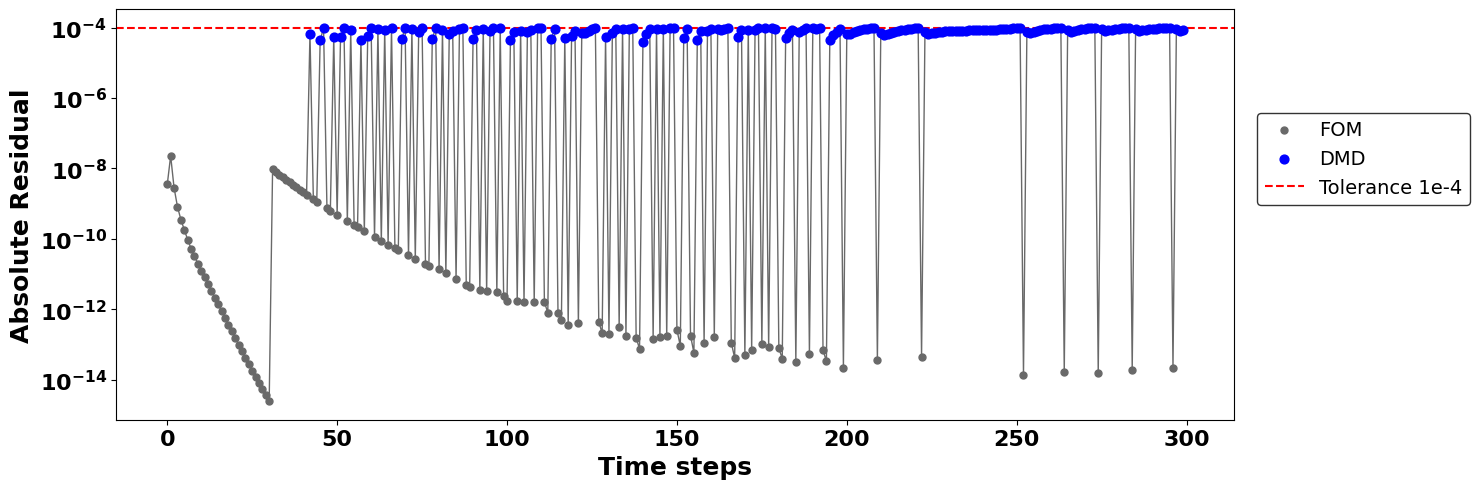

In [55]:
import matplotlib.pyplot as plt

plt.style.use('default')

# Eje X
x = list(range(len(lista_residual_foam)))

# 🔧 Corregir desfase de índices (ii empieza en 1)
posicion_dmd_corr = [
    i - 1 for i in posicion_dmd
    if 0 < i <= len(lista_residual_foam)
]

plt.figure(figsize=(15, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# --- Línea FOM ---
plt.plot(
    x,
    lista_residual_foam,
    linestyle='-',
    linewidth=1,
    color='dimgray'
)

# --- Bolitas FOM ---
plt.scatter(
    x,
    lista_residual_foam,
    color='dimgray',
    s=25,
    label='FOM'
)

# --- Bolitas DMD ---
plt.scatter(
    posicion_dmd_corr,
    [lista_residual_foam[i] for i in posicion_dmd_corr],
    color='blue',
    s=40,
    zorder=5,
    label='DMD'
)

# --- Línea tolerancia ---
plt.axhline(
    y=1e-4,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Tolerance 1e-4'
)

plt.yscale('log')

plt.xlabel("Time steps", fontsize=18, fontweight='bold')
plt.ylabel("Absolute Residual", fontsize=18, fontweight='bold')

# 🔥 Números de los ejes más grandes y en negrita
ax.tick_params(axis='both', labelsize=16)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

plt.grid(False)

# 🔥 Leyenda más a la derecha
plt.legend(
    fontsize=14,
    loc='lower right',
    bbox_to_anchor=(1.22, 0.5),  # <-- mueve horizontalmente
    frameon=True,
    facecolor='white',
    edgecolor='black'
)

plt.tight_layout()
plt.show()

## Evolution of the DMD Rank During the Simulation

An important aspect of Dynamic Mode Decomposition is the dimensionality of the reduced representation generated from the available snapshot data. The effective rank of the DMD model provides information about the complexity of the flow dynamics captured by the reduced-order approximation and indicates how many dominant modes are required to represent the solution evolution.

In the adaptive FOM–DMD framework, new snapshots are continuously incorporated into the database as the simulation progresses. Consequently, the DMD decomposition is recomputed at each update stage, leading to a time-dependent variation of the rank associated with the reduced-order model.

For both velocity and pressure fields, the rank corresponds to the number of dominant modes retained after the singular value decomposition (SVD) performed internally by the DMD algorithm. Let the snapshot matrix be represented by

$$
\mathbf{X}
=

\begin{bmatrix}
\mathbf{x}_1 &
\mathbf{x}_2 &
\cdots &
\mathbf{x}_m
\end{bmatrix},
$$

where each column corresponds to a solution snapshot collected during the simulation.

The DMD procedure relies on the singular value decomposition

$$
\mathbf{X}
=

\mathbf{U}
\mathbf{\Sigma}
\mathbf{V}^{T},
$$

where the diagonal matrix

$$
\mathbf{\Sigma}
=

\mathrm{diag}
\left(
\sigma_1,\sigma_2,\ldots,\sigma_r
\right)
$$

contains the singular values ordered according to their energetic contribution.

The effective rank of the DMD model is therefore associated with the number of significant singular values retained in the reduced representation. A low rank indicates that the dynamics can be described using a small number of coherent structures, whereas a larger rank suggests the presence of more complex flow behavior requiring additional modes.

The left panel of the figure presents the evolution of the rank associated with the velocity snapshot matrix throughout the simulation. Since the velocity field contains the dominant dynamical information of the flow, variations in the velocity rank provide insight into the evolution of the principal coherent structures captured by the reduced-order model.

The right panel displays the corresponding rank evolution for the pressure snapshot matrix. Although pressure is coupled to the velocity field through the incompressibility constraint, its modal structure may exhibit different characteristics, resulting in a distinct rank evolution over time.

Monitoring the DMD rank serves several purposes:

* It provides a quantitative measure of the complexity of the flow dynamics captured by the reduced-order model.
* It allows verification that the reduced basis remains sufficiently compact throughout the simulation.
* It indicates whether the incorporation of new snapshots introduces additional dynamical structures that must be represented by the reduced-order approximation.
* It helps evaluate the balance between model accuracy and computational efficiency, since larger ranks generally lead to higher computational costs during the reduced-order prediction stage.

Consequently, the evolution of the DMD rank constitutes an important diagnostic metric for assessing the behavior, adaptability, and robustness of the online reduced-order modeling framework.


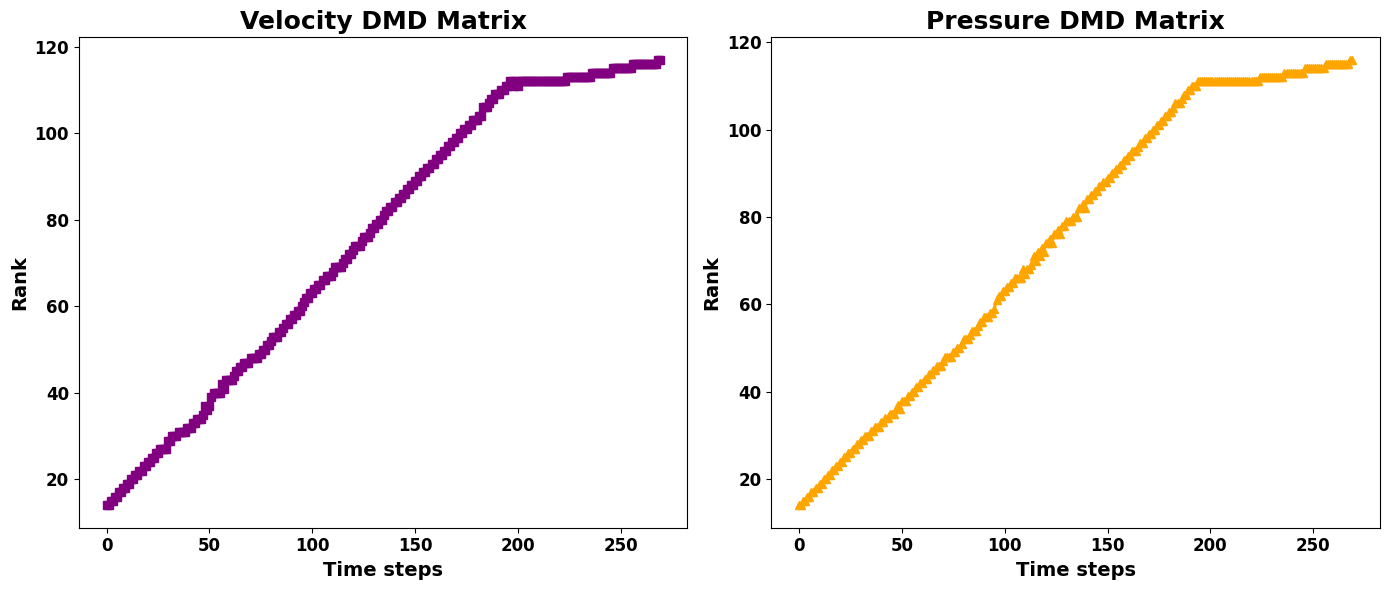

In [56]:
import matplotlib.pyplot as plt


time_steps_pre = range(len(lista_rank_dmd_pre))

time_steps_vel = range(len(lista_rank_dmd_vel))

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# =========================
# Velocity DMD Matrix (izquierda)
# =========================
axes[0].plot(time_steps_vel,
             lista_rank_dmd_vel,
             color='purple',
             marker='s',
             markersize=6,
             linewidth=2)

axes[0].set_title("Velocity DMD Matrix", fontsize=18, fontweight='bold')
axes[0].set_xlabel("Time steps", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Rank", fontsize=14, fontweight='bold')

axes[0].tick_params(axis='both', labelsize=12)
for label in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    label.set_fontweight('bold')


# =========================
# Pressure DMD Matrix (derecha)
# =========================
axes[1].plot(time_steps_pre,
             lista_rank_dmd_pre,
             color='orange',
             marker='^',
             markersize=6,
             linewidth=2)

axes[1].set_title("Pressure DMD Matrix", fontsize=18, fontweight='bold')
axes[1].set_xlabel("Time steps", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Rank", fontsize=14, fontweight='bold')

axes[1].tick_params(axis='both', labelsize=12)
for label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()